In [ ]:
!pip install pandas numpy matplotlib seaborn pymatgen scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.3 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=6b08170b7608dd7b20bc959404c8034a132e58a4dc7537c1f8402a5c8f170d85
  Stor

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from pymatgen.core import Composition

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

df = pd.read_csv("/content/drive/MyDrive/dsa210/materials_featurized.csv")
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")

# Drop rows with missing target variable
df = df.dropna(subset=['magnetization_per_fu'])

# Fill missing band_gap with 0 (metals have no gap)
df['band_gap'] = df['band_gap'].fillna(0)

print(f"Clean dataset: {len(df)} rows")
print(f"\nOrdering counts:")
print(df['ordering'].value_counts())

Loaded 18415 rows, 24 columns
Clean dataset: 18415 rows

Ordering counts:
ordering
NM     5000
FM     5000
FiM    5000
AFM    3415
Name: count, dtype: int64


## Distribution by Ordering Type

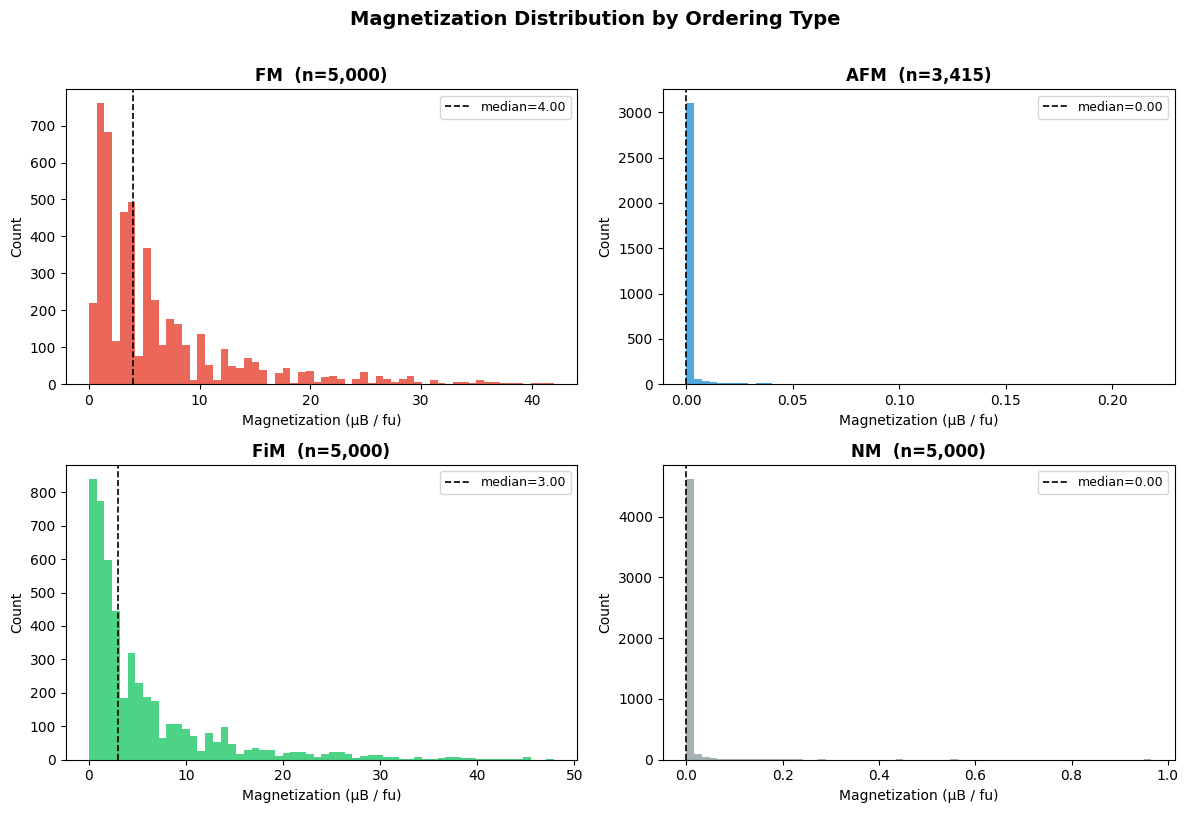

In [ ]:
ordering_colors = {'FM': '#e74c3c', 'AFM': '#3498db', 'FiM': '#2ecc71', 'NM': '#95a5a6'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # convert 2x2 grid into a flat list so it can loop over it with a single index

for i, otype in enumerate(['FM', 'AFM', 'FiM', 'NM']):
    subset = df[df['ordering'] == otype]['magnetization_per_fu']  # get magnetization values for this ordering type only
    upper = subset.quantile(0.99)  # find 99th percentile to cut off extreme outliers
    axes[i].hist(subset[subset <= upper], bins=60,
                 color=ordering_colors[otype], edgecolor='none', alpha=0.85)  # plot histogram without top 1% outliers
    axes[i].set_title(f'{otype}  (n={len(subset):,})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Magnetization (\u03bcB / fu)')
    axes[i].set_ylabel('Count')
    axes[i].axvline(subset.median(), color='black', linestyle='--', linewidth=1.2,
                    label=f'median={subset.median():.2f}')  # draw a line at the median
    axes[i].legend(fontsize=9)

plt.suptitle('Magnetization Distribution by Ordering Type', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dsa210/eda_plots/magnetization_distribution_orderingtype.png", bbox_inches='tight')
plt.show()

##Correlation Heatmap

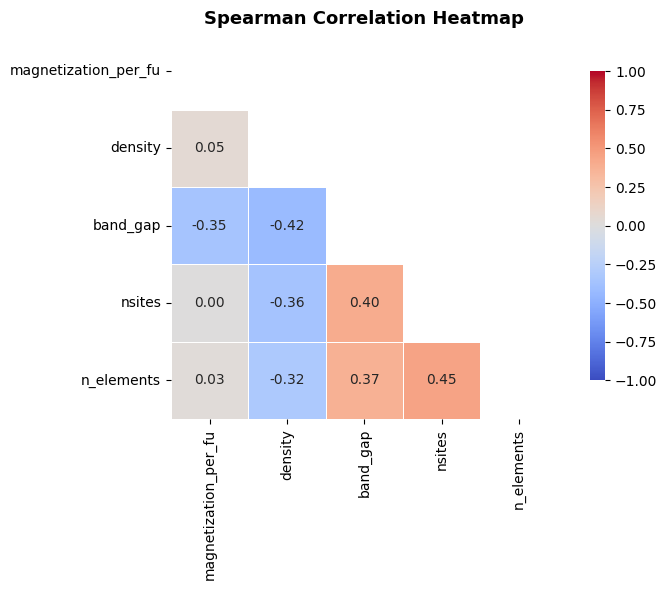

In [ ]:
num_cols = ['magnetization_per_fu', 'density', 'band_gap', 'nsites', 'n_elements']  # numerical columns to check correlations between
corr = df[num_cols].corr(method='spearman')  # compute spearman correlation matrix (used spearman because of skewed data)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # create a mask for the upper triangle to only show the bottom half

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,        # center colormap at 0, red=positive blue=negative correlation
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

ax.set_title('Spearman Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dsa210/eda_plots/correlation_heatmap.png", bbox_inches='tight')
plt.show()

## Magnetic Element Fraction



In [ ]:
# Set of elements known to carry magnetic moments based on their electron configuration
MAGNETIC_ELEMENTS = {
    'Fe', 'Co', 'Ni', 'Mn', 'Cr', 'Cu', 'V',           # 3d transition metals
    'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Nd', 'Sm',    # rare earth elements
    'Eu', 'Yb', 'Ce', 'Pr'                               # rare earth elements
}

def magnetic_element_fraction(formula):
    try:
        comp = Composition(formula)  # parse the chemical formula string into a pymatgen Composition object
        total = sum(comp.values())   # total number of atoms in the formula unit
        mag_count = sum(v for el, v in comp.items() if str(el) in MAGNETIC_ELEMENTS)  # count only atoms that are magnetic elements
        return mag_count / total     # return fraction
    except:
        return 0.0  # if formula can't be parsed, assume no magnetic elements

df['mag_element_fraction'] = df['formula'].apply(magnetic_element_fraction)  # apply the function to every row
print(df[['formula', 'ordering', 'mag_element_fraction']].head(10))

           formula ordering  mag_element_fraction
0     Ba2Mg(TiS3)2       NM              0.000000
1      InHg6As4Cl7       NM              0.000000
2         Yb2InPd2       NM              0.400000
3          LaNi5P3       NM              0.555556
4           SbKrF7       NM              0.000000
5  Na3La2Hf2P5SO24       NM              0.000000
6        Ca(SiO2)6       NM              0.000000
7       CuBi(WO4)2       NM              0.083333
8       Ca(NdTe2)2       NM              0.285714
9  Na7NbSi6(SnO8)3       NM              0.000000


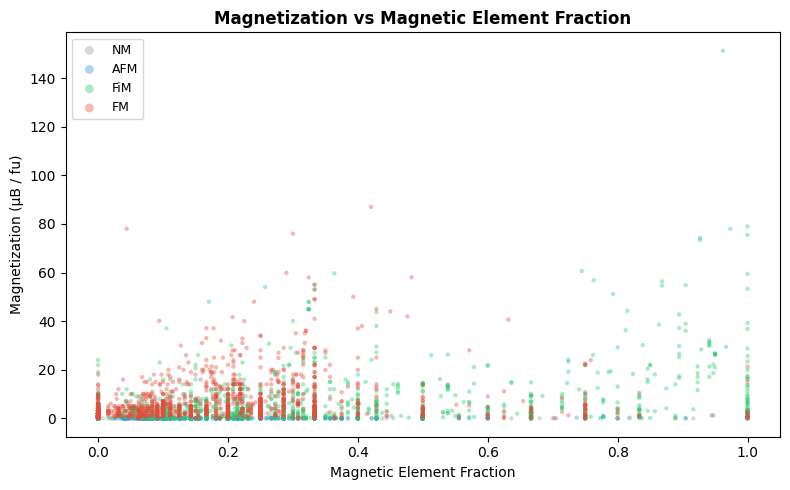

In [ ]:
palette = {'FM': '#e74c3c', 'AFM': '#3498db', 'FiM': '#2ecc71', 'NM': '#95a5a6'}

fig, ax = plt.subplots(figsize=(8, 5))

sample2 = df.sample(min(5000, len(df)), random_state=0)  # sample 5000 random points to avoid overplotting

for otype in ['NM', 'AFM', 'FiM', 'FM']:  # plot FM last so its dots appear on top
    sub = sample2[sample2['ordering'] == otype]  # filter to just this ordering type
    ax.scatter(sub['mag_element_fraction'], sub['magnetization_per_fu'],
               c=palette[otype], label=otype, alpha=0.4, s=10, edgecolors='none')  # semi-transparent dots

ax.set_xlabel('Magnetic Element Fraction')
ax.set_ylabel('Magnetization (\u03bcB / fu)')
ax.set_title('Magnetization vs Magnetic Element Fraction', fontsize=12, fontweight='bold')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dsa210/eda_plots/mag_element_fraction_scatter.png", bbox_inches='tight')
plt.show()

## Magpie Feature Distributions

12 Magpie features found in dataset


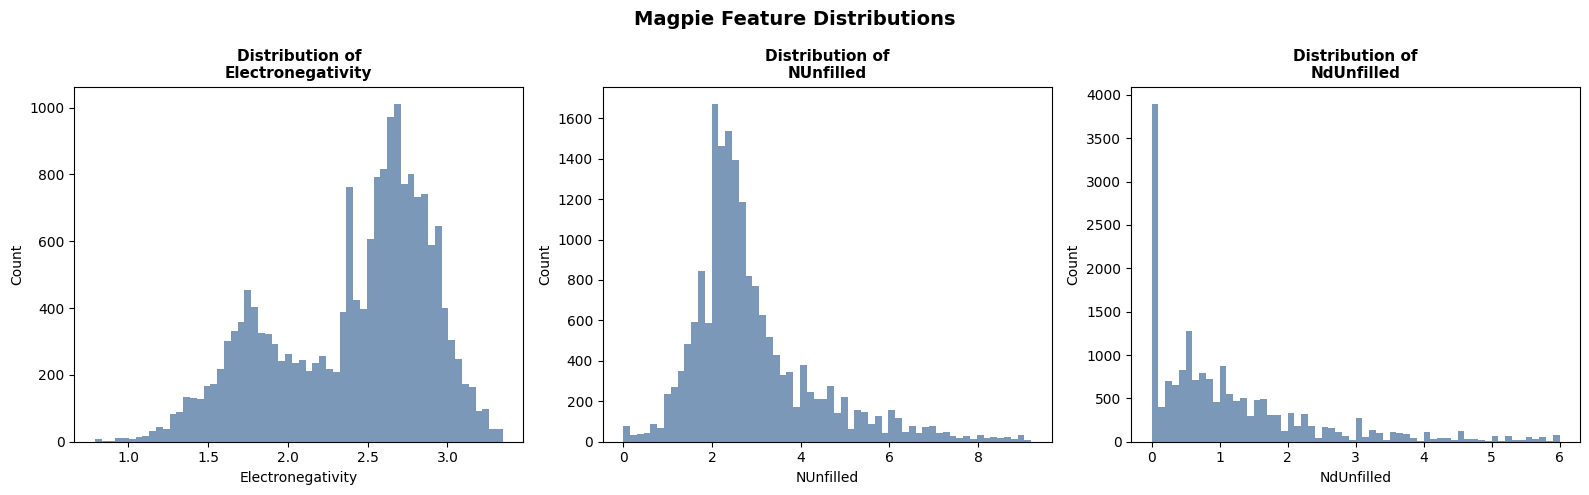

In [ ]:
# Confirm the Magpie columns are present
magpie_cols = [c for c in df.columns if 'MagpieData' in c]
print(f"{len(magpie_cols)} Magpie features found in dataset")

# Three features to explore, using mean as the main statistic
magpie_features = [
    'MagpieData mean Electronegativity',
    'MagpieData mean NUnfilled',
    'MagpieData mean NdUnfilled',
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, magpie_features):
    upper = df[feat].quantile(0.99)  # cut top 1% outliers
    subset = df[df[feat] <= upper][feat]
    ax.hist(subset, bins=60, color='#5b7fa6', edgecolor='none', alpha=0.8)
    ax.set_title(f'Distribution of\n{feat.replace("MagpieData mean ", "")}', fontsize=11, fontweight='bold')
    ax.set_xlabel(feat.replace("MagpieData mean ", ""))
    ax.set_ylabel('Count')

plt.suptitle('Magpie Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dsa210/eda_plots/magpie_distributions.png', bbox_inches='tight')
plt.show()

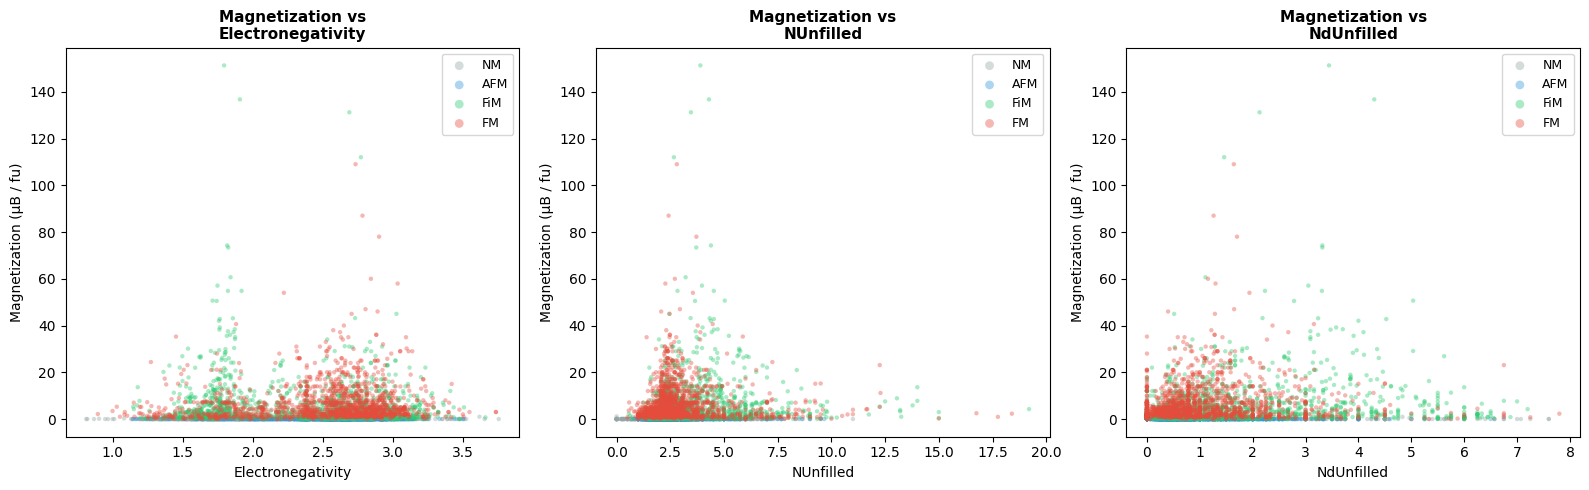

In [ ]:
sample3 = df.sample(min(5000, len(df)), random_state=1)  # 5000 random points to avoid overplotting

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, magpie_features):
    for otype in ['NM', 'AFM', 'FiM', 'FM']:
        sub = sample3[sample3['ordering'] == otype]
        ax.scatter(sub[feat], sub['magnetization_per_fu'],
                   c=palette[otype], label=otype,
                   alpha=0.4, s=10, edgecolors='none')
    ax.set_xlabel(feat.replace("MagpieData mean ", ""))
    ax.set_ylabel('Magnetization (\u03bcB / fu)')
    ax.set_title(f'Magnetization vs\n{feat.replace("MagpieData mean ", "")}', fontsize=11, fontweight='bold')
    ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dsa210/eda_plots/magpie_scatter.png', bbox_inches='tight')
plt.show()